In [532]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [533]:
df = pd.read_json('../data/Prepared/car_data.json')

## Data contract (Data Dictionary + Validity Rules)

The dataset in `data/raw/car_data.json` and `data/Prepared/car_data.json` currently uses the same column schema. The table below documents the expected meaning, type, and validation rules for each field.

So this works as checklist when cleaning data.

| Column | Meaning | Type | Valid range/values | Units | Notes |
| --- | --- | --- | --- | --- | --- |
| `url` | listing URL | string | expected to be a valid OLX posting URL | - | should identify a posting, but duplicates are present in the current data |
| `posting_date` | date the listing was posted | date string | usually `DD.MM.YYYY`; some rows use relative text such as `Сегодня` | date | must be normalized before date parsing |
| `region` | seller region in Uzbekistan | category | 13 observed region values including `Tashkent`, `Samarkand`, `Bukhara`, `Karakalpakstan` | - | 1 missing value observed |
| `district` | district or city within a region | category | 230 observed values | - | spelling and naming normalization may be needed |
| `price` | listed sale price | numeric stored as string | positive values; observed range `10,000,000` to `2,008,972,671` | local currency | 5 missing values observed; outliers should be reviewed |
| `currency` | currency code for `price` | category | mostly `UZS` when present | ISO currency code | highly sparse in the current data; many rows are missing |
| `description` | free-text ad description | text | arbitrary seller-written text | - | noisy multilingual text; useful for NLP/features after cleaning |
| `image_url` | main image link for the ad | string | expected `http`/`https` image URL | - | optional; missing values are present |
| `seller_type` | seller classification | category | mostly `private` in observed data | - | many missing values; could later include dealer/business labels |
| `model` | vehicle model name | category/text | 720 observed values | - | may mix trims, generations, and inconsistent naming |
| `body_type` | vehicle body style | category | `Sedan`, `Hatchback`, `Station Wagon`, `SUV`, `Minivan`, `Pickup`, `Coupe`, `Convertible`, `Other` | - | appears complete in the current snapshot |
| `sale_type` | sale terms attached to the listing | multi-label text/category | values such as `Simple Sale`, `Credit`, `Installment`, `Exchange`, `Rent`, often comma-separated combinations | - | multilingual and highly inconsistent; many missing values |
| `year` | vehicle manufacture year | integer stored as string | observed range `1900` to `2025` | year | should be checked against realistic car production years |
| `mileage` | vehicle mileage | integer stored as string | observed range `0` to `10,000,000` | km | missing values and obvious outliers are possible |
| `transmission` | gearbox type | category | `Manual`, `Automatic`, `Other` | - | appears complete in the current snapshot |
| `color` | vehicle color | category | 23 observed color values such as `White`, `Black`, `Gray`, `Blue` | - | synonyms may need consolidation |
| `engine_volume` | engine size | numeric stored as string | observed range `1` to `10000` | unclear/mixed | scale is inconsistent across rows and likely needs normalization before analysis |
| `fuel_type` | fuel system | category | `Gasoline/Gas`, `Gasoline`, `Electric`, `Hybrid`, `Diesel`, `Other` | - | appears complete in the current snapshot |
| `condition` | vehicle condition | category | `Excellent`, `Good`, `Average`, `Needs Repair` | - | ordinal meaning should be preserved if encoded |
| `owners_count` | number of previous owners | ordinal category stored as string | `1`, `2`, `3`, `4+` | owners | missing values are present; `4+` is grouped rather than exact |
| `additional_options` | extra features/options listed in the ad | comma-separated text list | examples include `Customs Cleared`, `Electrical Window Lifters`, parking sensors, etc. | - | multi-valued field; multilingual, sparse, and suitable for splitting into tags |

## Data intake & first checks

### Basic intake checklist:

In [534]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49273 entries, 0 to 49272
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 49273 non-null  object 
 1   posting_date        49122 non-null  object 
 2   region              49121 non-null  object 
 3   district            49121 non-null  object 
 4   price               49117 non-null  object 
 5   currency            14587 non-null  object 
 6   description         49122 non-null  object 
 7   image_url           46384 non-null  object 
 8   seller_type         40662 non-null  object 
 9   model               49056 non-null  object 
 10  body_type           49122 non-null  object 
 11  sale_type           20430 non-null  object 
 12  year                49122 non-null  float64
 13  mileage             45496 non-null  float64
 14  transmission        49122 non-null  object 
 15  color               49122 non-null  object 
 16  engine_vo

### Uniqueness + duplicates

In [535]:
before = len(df)
print(f'Shape: {df.shape[0]}, {df.shape[1]}. Unique values: {df['url'].nunique()}')
df_clean = df.drop_duplicates(subset='url', keep='first').copy()
print(f'Removed elements: {before - len(df_clean)}')

Shape: 49273, 21. Unique values: 48273
Removed elements: 1000


### Target integrity check

The target variable (price) represents seller-listed prices, which may include noise due to negotiation strategies and inconsistent reporting.

##  Data quality audit (prove what’s wrong before fixing)

Data quality audit

|Column|% missing |Is missing acceptable?|Why might it be missing?|
|---|---|---|---|
|currency|73%|No|Scraper could not identify USD currency|
|sale_type|60%|Maybe|Sales type not included in description|
|model|1%|No|Model not included in description|
|mileage|7%|Yes(moderate, manageable)|Seller may be hide high usage, older listings may not include it|
|additional_options|34%|Yes|User forgot to include or none exist|

## Cleaning strategy (not just steps-decisions)

In [536]:
df_clean.tail(100)

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model,...,sale_type,year,mileage,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options
49173,https://olx.uz/d/obyavlenie/srochno-sotiladi-I...,Опубликовано18 апреля 2026,Tashkent,Паркент,30000000,UZS,Описание Assalomu alaykum mashina modeli nexia...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Nexia,...,Simple Sale,2006.0,350000.0,Manual,Silver,85.0,Gasoline/Gas,Average,1,Electrical Window Lifters
49174,https://olx.uz/d/obyavlenie/gaz-31-105-moshina...,Опубликовано18 апреля 2026,Surkhandarya,Карлук,30000000,UZS,Описание Gaz 31 105 Volga sotiladi yili 2005 p...,https://ninja.data.olxcdn.com,private,31105,...,"Простая продажа, Рассрочка, Аренда",2005.0,NaN,Manual,Blue,2.0,Gasoline/Gas,Good,1,None
49175,https://olx.uz/d/obyavlenie/ford-eskord-pekap-...,Опубликовано18 апреля 2026,Syrdarya,Баяут,30000000,UZS,Описание Mashina xolati juda yaxshi mator yang...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Escort,...,Simple Sale,1995.0,350.0,Manual,Blue,1.0,Gasoline/Gas,Excellent,1,Electrical Window Lifters
49176,https://olx.uz/d/obyavlenie/best-matez-barterg...,Опубликовано18 апреля 2026,Samarkand,Иштыхан,30000000,UZS,Описание Matez mator moy yimiydi yili 2008 met...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Matiz,...,Simple Sale,2008.0,328000.0,Manual,White,15.0,Gasoline/Gas,Average,1,Air Conditioner
49177,https://olx.uz/d/obyavlenie/matiz-sotiladi-xol...,Опубликовано17 апреля 2026,Samarkand,Пайшанба,30000000,UZS,Описание Matiz sotiladi uchtalik narxi 30 Mi...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Matiz,...,None,2008.0,NaN,Manual,Gray,49.0,Gasoline,Good,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49268,https://olx.uz/d/obyavlenie/matiz-vest-satylad...,Опубликовано05 мая 2026,Karakalpakstan,Ходжейли,30000000,UZS,Описание Матиз вест жылы2009 машын жұрып тұр 3...,https://ninja.data.olxcdn.com,private,Matiz,...,Simple Sale,2009.0,3590000.0,Manual,White,1111.0,Gasoline/Gas,Good,1,Customs Cleared
49269,https://olx.uz/d/obyavlenie/nexia-1-sotiladi-p...,Опубликовано05 мая 2026,Bukhara,Бухара,30000000,UZS,Описание Nexia 1 sotiladi yurip turgan moshina...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Nexia,...,Simple Sale,1998.0,1234.0,Manual,White,15.0,Gasoline/Gas,Excellent,1,"Electrical Mirrors, Electrical Window Lifters"
49270,https://olx.uz/d/obyavlenie/ford-pasajer-1991-...,Опубликовано04 мая 2026,Navoi,Навои,30000000,UZS,"Описание Yili 1991 4ta yangi balon, kalotka Sa...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Transit,...,Simple Sale,1991.0,0.0,Manual,Blue,2.0,Diesel,Good,1,None
49271,https://olx.uz/d/obyavlenie/matiz-oq-2004-yil-...,Опубликовано04 мая 2026,Tashkent,ТашкентЯшнабадский район,30000000,UZS,Описание Matiz Rangi oq Yili 2004 Holati yaxsh...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Matiz,...,None,2004.0,286000.0,Manual,White,1.0,Gasoline,Good,None,None


### Standardization rules (categorical)

#### Starting off with `model` column

In [537]:
df_clean['district'].value_counts()

district
Samarkand                      2844
TashkentSergeliyskiy rayon     2440
TashkentYunusabadskiy rayon    2346
Buhara                         2274
TashkentChilanzarskiy rayon    1940
                               ... 
Ходжикент                         1
Дехканабад                        1
Ангор                             1
Гузалкент                         1
Куйганъяр                         1
Name: count, Length: 425, dtype: int64

The original model column contained inconsistent representations, including numeric codes, partial names, and mixed-language values. A mapping dictionary was created to standardize these into unified car names and extract brand information, improving feature quality for modeling.

In [538]:
model_to_name = {

    # LADA (VAZ)
    "2101": "Lada 2101",
    "2102": "Lada 2102",
    "2103": "Lada 2103",
    "2104": "Lada 2104",
    "2105": "Lada 2105",
    "2106": "Lada 2106",
    "2107": "Lada 2107",
    "2108": "Lada Samara 2108",
    "2109": "Lada Samara 2109",
    "21099": "Lada Samara 21099",
    "21011": "Lada 21011",
    "21013": "Lada 21013",
    "21033": "Lada 21033",
    "21060": "Lada 21060",
    "21061": "Lada 21061",
    "21063": "Lada 21063",
    "21071": "Lada 21071",
    "21073": "Lada 21073",
    "21083": "Lada Samara 21083",
    "21093": "Lada Samara 21093",
    "21102": "Lada 21102",
    "21103": "Lada 21103",
    "21106": "Lada 21106",
    "21111": "Lada 21111",
    "21124": "Lada 21124",
    "2121 Нива": "Lada Niva",
    "21214 Niva": "Lada Niva 21214",
    "4x4": "Lada Niva 4x4",
    "Дана": "Lada Niva Dana",
    "Kalina": "Lada Kalina",
    "1117 Kalina универсал": "Lada Kalina Wagon",
    "1118 Kalina седан": "Lada Kalina Sedan",
    "1119 Kalina хэтчбэк": "Lada Kalina Hatchback",
    "2110": "Lada 2110",
    "2111": "Lada 2111",
    "2112": "Lada 2112",
    "2113": "Lada 2113",
    "2114": "Lada 2114",
    "2115": "Lada 2115",

    # GAZ — Volga
    "21": "GAZ 21 Volga",
    "21М": "GAZ 21 Volga",
    "21Р": "GAZ 21 Volga",
    "21УС": "GAZ 21 Volga",
    "22": "GAZ 22 Volga",
    "24": "GAZ 24 Volga",
    "2401": "GAZ 2401",
    "2402": "GAZ 2402",
    "2410": "GAZ 2410 Volga",
    "3102": "GAZ 3102 Volga",
    "3102i": "GAZ 3102i",
    "31013": "GAZ 31013",
    "31029": "GAZ 31029",
    "3110": "GAZ 3110",
    "3111": "GAZ 3111",

    # GAZ — Pobeda
    "M-20": "GAZ Pobeda M-20",
    "20": "GAZ Pobeda",
    "20М": "GAZ Pobeda",

    # GAZ — Chaika / ZIM / M1
    "13 Чайка": "GAZ 13 Chaika",
    "ЗИМ": "GAZ 12 ZIM",
    "12 ЗИМ": "GAZ 12 ZIM",
    "М1": "GAZ M1",

    # GAZ — off-road / trucks
    "69": "GAZ 69",
    "51": "GAZ 51",
    "66": "GAZ 66",
    "67": "GAZ 67",

    # MOSKVICH / IZH
    "400": "Moskvich 400",
    "401": "Moskvich 401",
    "407": "Moskvich 407",
    "410": "Moskvich 410",
    "412": "Moskvich 412",
    "412 Э": "Moskvich 412",
    "2125 Комби": "Moskvich 2125 Kombi",
    "2136 Kombi": "Moskvich 2136 Kombi",
    "2137 Kombi": "Moskvich 2137 Kombi",
    "ASLK 2137": "Moskvich 2137",
    "2140": "Moskvich 2140",
    "ASLK 2140": "Moskvich 2140",
    "2141": "Moskvich 2141",
    "21412": "Moskvich 21412",

    # UAZ
    "469": "UAZ 469",
    "469Б": "UAZ 469",
    "2206": "UAZ 2206",
    "2715": "UAZ 2715",
    "3151": "UAZ 3151",
    "3159": "UAZ 3159",
    "3303": "UAZ 3303",
    "31512-010": "UAZ 31512",
    "31514-012": "UAZ 31514",
    "31519-010": "UAZ 31519",
    "Hunter": "UAZ Hunter",

    # ZAZ
    "965": "ZAZ 965",
    "968": "ZAZ 968",
    "968M": "ZAZ 968M",
    "1102 Таврия": "ZAZ Tavria",
    "1102": "ZAZ Tavria",
    "1111 Ока": "ZAZ Oka",
    "Sens": "ZAZ Sens",

    # DAEWOO (very important in Uzbekistan)
    "Matiz": "Daewoo Matiz",
    "Nexia": "Daewoo Nexia",
    "Damas": "Daewoo Damas",
    "Tico": "Daewoo Tico",
    "Espero": "Daewoo Espero",

    # CHEVROLET (UzAuto)
    "Lacetti": "Chevrolet Lacetti",
    "Gentra": "Chevrolet Gentra",
    "Cobalt": "Chevrolet Cobalt",
    "Spark": "Chevrolet Spark",
    "Malibu": "Chevrolet Malibu",
    "Tracker": "Chevrolet Tracker",
    "Onix": "Chevrolet Onix",
    "Captiva": "Chevrolet Captiva",

    # HYUNDAI
    "Sonata": "Hyundai Sonata",
    "Accent": "Hyundai Accent",
    "Elantra": "Hyundai Elantra",

    # KIA
    "Rio": "Kia Rio",
    "Sportage": "Kia Sportage",

    # VOLKSWAGEN
    "Passat": "Volkswagen Passat",
    "Golf": "Volkswagen Golf",
    "Golf III": "Volkswagen Golf III",
    "Golf VI": "Volkswagen Golf VI",
    "Jetta": "Volkswagen Jetta",
    "Transporter": "Volkswagen Transporter",
    "Scirocco": "Volkswagen Scirocco",

    # NISSAN
    "Maxima": "Nissan Maxima",
    "Skyline GT-R": "Nissan Skyline GT-R",
    "Bluebird": "Nissan Bluebird",
    "R Nessa": "Nissan R'nessa",
    "Pathfinder": "Nissan Pathfinder",

    # TOYOTA
    "Corolla": "Toyota Corolla",
    "Camry": "Toyota Camry",
    "Hiace": "Toyota Hiace",
    "Lite Ace": "Toyota LiteAce",
    "Starlet": "Toyota Starlet",

    # FORD
    "Escort": "Ford Escort",
    "Fiesta": "Ford Fiesta",
    "Scorpio": "Ford Scorpio",
    "Granada": "Ford Granada",
    "Five Hundred": "Ford Five Hundred",

    # MERCEDES-BENZ
    "190": "Mercedes-Benz 190",
    "C 250": "Mercedes-Benz C250",
    "E 230": "Mercedes-Benz E230",
    "SL 320": "Mercedes-Benz SL320",
    "S 550": "Mercedes-Benz S550",

    # BMW
    "520": "BMW 520",

    # HONDA
    "Civic": "Honda Civic",

    # OPEL
    "Vectra": "Opel Vectra",
    "Omega": "Opel Omega",
    "Ascona": "Opel Ascona",
    "Rekord": "Opel Rekord",
    "Admiral": "Opel Admiral",
    "Vivaro": "Opel Vivaro",

    # FIAT
    "Uno": "Fiat Uno",
    "Croma": "Fiat Croma",

    # garbage / unknown
    "Прочее": None,
    "Другая": None,
    "Pickup": None,
    "eT7": None,
    "51": None,   # truck — exclude from car analysis
    "66": None,   # truck
    "67": None,   # military jeep
}

In [539]:
brand_map = {

    # Daewoo
    "Tico": "Daewoo",
    "Matiz": "Daewoo",
    "Nexia": "Daewoo",
    "Damas": "Daewoo",
    "Espero": "Daewoo",

    # Chevrolet (UzAuto)
    "Lacetti": "Chevrolet",
    "Spark": "Chevrolet",
    "Cobalt": "Chevrolet",
    "Malibu": "Chevrolet",
    "Tracker": "Chevrolet",
    "Onix": "Chevrolet",
    "Gentra": "Chevrolet",
    "Captiva": "Chevrolet",

    # Volkswagen
    "Passat": "Volkswagen",
    "Golf": "Volkswagen",
    "Golf III": "Volkswagen",
    "Golf VI": "Volkswagen",
    "Jetta": "Volkswagen",
    "Transporter": "Volkswagen",
    "Scirocco": "Volkswagen",

    # Nissan
    "Maxima": "Nissan",
    "Skyline GT-R": "Nissan",
    "Bluebird": "Nissan",
    "R Nessa": "Nissan",
    "Pathfinder": "Nissan",

    # Hyundai
    "Sonata": "Hyundai",
    "Accent": "Hyundai",
    "Elantra": "Hyundai",

    # Kia
    "Rio": "Kia",
    "Sportage": "Kia",

    # Toyota
    "Corolla": "Toyota",
    "Camry": "Toyota",
    "Hiace": "Toyota",
    "Lite Ace": "Toyota",

    # Ford
    "Escort": "Ford",
    "Fiesta": "Ford",
    "Scorpio": "Ford",

    # Mercedes-Benz
    "190": "Mercedes-Benz",
    "C 250": "Mercedes-Benz",
    "SL 320": "Mercedes-Benz",

    # BMW
    "520": "BMW",

    # Opel
    "Vectra": "Opel",
    "Omega": "Opel",
    "Ascona": "Opel",
    "Rekord": "Opel",

    # Fiat
    "Uno": "Fiat",
    "Croma": "Fiat",

    # UAZ
    "469": "UAZ",
    "469Б": "UAZ",
    "3151": "UAZ",
    "3159": "UAZ",
    "3303": "UAZ",
    "2206": "UAZ",

    # ZAZ
    "968": "ZAZ",
    "968M": "ZAZ",
    "1102 Таврия": "ZAZ",
    "1102": "ZAZ",
    "1111 Ока": "ZAZ",

    # Moskvich / IZH
    "412": "Moskvich",
    "412 Э": "Moskvich",
    "2140": "Moskvich",
    "2141": "Moskvich",
    "21412": "Moskvich",
    "ASLK 2140": "Moskvich",
    "ASLK 2137": "Moskvich",
    "2137 Kombi": "Moskvich",
    "2136 Kombi": "Moskvich",

    # GAZ
    "24": "GAZ",
    "2410": "GAZ",
    "2401": "GAZ",
    "2402": "GAZ",
    "3102": "GAZ",
    "31029": "GAZ",
    "3110": "GAZ",
    "3102i": "GAZ",

    # Lada (VAZ)
    "2101": "Lada",
    "2102": "Lada",
    "2103": "Lada",
    "2104": "Lada",
    "2105": "Lada",
    "2106": "Lada",
    "2107": "Lada",
    "2108": "Lada",
    "2109": "Lada",
    "21011": "Lada",
    "21013": "Lada",
    "21051": "Lada",
    "21061": "Lada",
    "21071": "Lada",
    "21073": "Lada",
    "21083": "Lada",
    "21093": "Lada",
    "21099": "Lada",

    "2110": "Lada",
    "2111": "Lada",
    "2113": "Lada",
    "21106": "Lada",
    "21124": "Lada",

    "2121 Нива": "Lada",
    "21214 Niva": "Lada",
    "4x4": "Lada",

    "1117 Kalina универсал": "Lada",
    "1118 Kalina седан": "Lada",
    "1119 Kalina хэтчбэк": "Lada",

    # fallback garbage
    "Прочее": None,
    "Другая": None,
}

In [540]:
df_clean['model_clean'] = df_clean['model'].str.replace(":","", regex=False).str.strip()
print('Removed ":"')
df_clean['car_name'] = df_clean['model_clean'].map(model_to_name)


Removed ":"


In [541]:
def assign_brand(model):
    if model.isdigit():
        num = int(model)

        if 2100 <= num <= 2199:
            return 'Lada'
        
        elif num in [24, 31, 3102, 31029, 3110]:
            return 'GAZ'
        
        elif num in [80, 100, 200, 50]:
            return 'Audi'
        
        elif num in [2140, 2141, 412]:
            return 'Moskvich'
    return None
def get_brand(model):
    model = str(model)

    brand = assign_brand(model)
    if brand:
        return brand
    
    for key in brand_map:
        if key.lower()in model.lower():
            return brand_map[key]
    return "Other"

In [542]:
df_clean["brand"] = df_clean["model_clean"].apply(get_brand)
df_clean["car_name"] = df_clean["car_name"].fillna(df_clean["model_clean"])

- `groupby()` is used to find model names to find common brands based on model names
- Not all data points are equally important — high-frequency categories contribute most to model performance.

In [543]:
df_clean.groupby('model_clean')['model_clean'].count().sort_values(ascending=False)

model_clean
Nexia         6669
Lacetti       4982
Matiz         4751
Damas         4014
Cobalt        3551
              ... 
Corolla II       1
21101            1
21101i           1
Charman          1
2138             1
Name: model_clean, Length: 734, dtype: int64

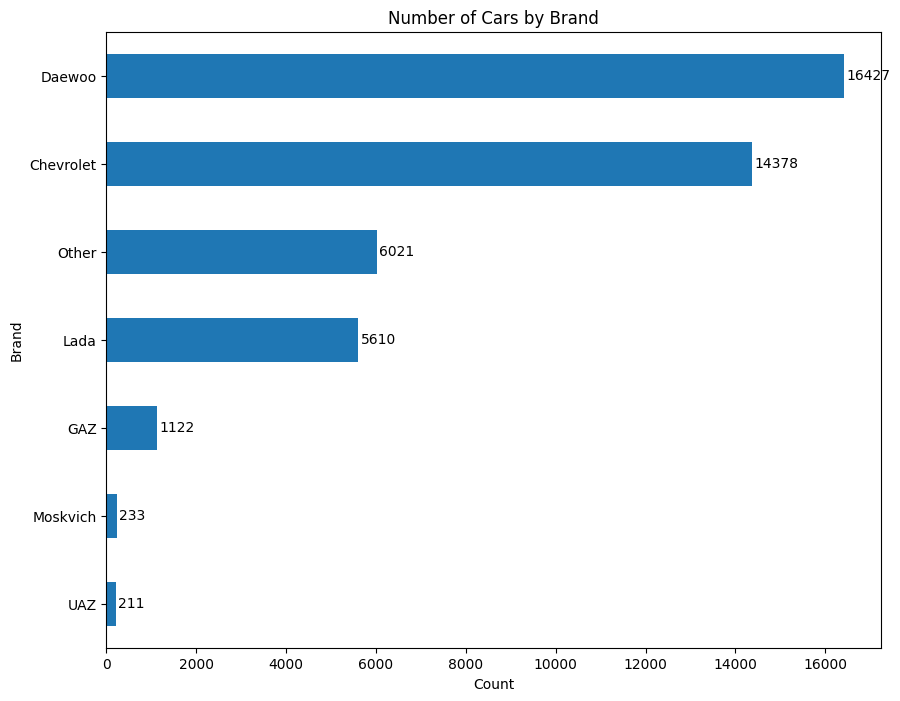

In [544]:
counts = df_clean.groupby('brand')['brand'].count().sort_values().tail(7)

ax = counts.plot(kind='barh', figsize=(10, 8))

for i, v in enumerate(counts):
    ax.text(v + 50, i, str(v), va='center')

plt.title("Number of Cars by Brand")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()


- **What you see (facts):**  
  `Daewoo` and `Chevrolet` brands have the highest sales volume.

- **What it might mean (interpretation):**  
  These vehicles are widely available and popular in the market.  
  They can be considered **`best sellers`**, meaning they sell quickly and do not remain listed for long.

- **What you would do next (action/decision):**  
  Proceed to the next data cleaning stage.  
  Expanding brand mapping further is unlikely to significantly improve the analysis.

In [545]:
df_clean['brand'] = df_clean['brand'].fillna('Other')

In [546]:
df_clean.head()

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,Manual,Red,12.0,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Manual,Green,1.0,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,Manual,White,2103.0,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,Manual,White,105.0,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,Manual,White,16.0,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other


In [547]:
df_clean = df_clean.rename(columns={"model":"model_raw"})

In [548]:
df_clean.head()

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model_raw,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,Manual,Red,12.0,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Manual,Green,1.0,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,Manual,White,2103.0,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,Manual,White,105.0,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,Manual,White,16.0,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other


In [549]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48273 entries, 0 to 49272
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 48273 non-null  object 
 1   posting_date        48122 non-null  object 
 2   region              48121 non-null  object 
 3   district            48121 non-null  object 
 4   price               48117 non-null  object 
 5   currency            14278 non-null  object 
 6   description         48122 non-null  object 
 7   image_url           45411 non-null  object 
 8   seller_type         39891 non-null  object 
 9   model_raw           48056 non-null  object 
 10  body_type           48122 non-null  object 
 11  sale_type           20038 non-null  object 
 12  year                48122 non-null  float64
 13  mileage             44535 non-null  float64
 14  transmission        48122 non-null  object 
 15  color               48122 non-null  object 
 16  engine_vo

---

#### Price & currency
- OLX uses USD currency as a default. In out data, UZS only precent but USD is missing.
- UZS will be swapped to USD to maintain consistency.

In [550]:
df_clean.groupby('currency')['currency'].count()

currency
USD      903
UZS    13375
Name: currency, dtype: int64

In [551]:
df_clean['currency'] = df_clean['currency'].fillna('USD')

In [552]:
df_clean.sample(5)

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model_raw,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
5432,https://olx.uz/d/obyavlenie/2115-lada-srochni-...,11.04.2025,Jizzakh,Dzhizak,30000000,UZS,65 temir baloni mator xadavoʻy kuzovlari yaxwi...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2115,...,Manual,Gray,15.0,Gasoline/Gas,Good,2,"Electrical Window Lifters, Customs Cleared",2115,Lada 2115,Lada
33788,https://olx.uz/d/obyavlenie/prodaetsya-kobolt-...,11.04.2025,Samarkand,Samarkand,12700..,USD,Состояние: Новое\nГод:2025\nПробег:0\nСчет фак...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Cobalt,...,Automatic,White,15.0,Gasoline,Excellent,1,None,Cobalt,Chevrolet Cobalt,Chevrolet
35968,https://olx.uz/d/obyavlenie/hyundai-santa-fe-f...,11.05.2025,Tashkent,TashkentYunusabadskiy rayon,45500..,USD,"2021, full option, \n2.5motor, \nkuzov brone p...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Santa FE,...,Automatic,Black,2500.0,Gasoline,Excellent,1,None,Santa FE,Santa FE,Other
19073,https://olx.uz/d/obyavlenie/labo-srochna-sotil...,10.04.2025,Samarkand,Gyulabad,8000..,USD,Лабо 2020 2021 \nПробег 121000\nМетан газ \nУр...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Damas,...,Manual,White,1.0,Gasoline/Gas,Excellent,1,None,Damas,Daewoo Damas,Daewoo
15438,https://olx.uz/d/obyavlenie/kobolt-2-evro-pozi...,26.04.2025,Tashkent,TashkentBektemirskiy rayon,7000..,USD,Кобальт в хорошем состоянии ходовка отличная р...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Cobalt,...,Manual,Black,16.0,Gasoline,Good,2,Air Conditioner,Cobalt,Chevrolet Cobalt,Chevrolet


In [553]:
exchange_rate = 12000

df_clean['price'] = pd.to_numeric(df_clean['price'].astype(str).str.replace(r'[^\d]', '', regex=True),
    errors='coerce'
)

df_clean['price_usd'] = df_clean['price']
df_clean.loc[df_clean['currency'] == 'UZS', 'price_usd'] = (
    df_clean.loc[df_clean['currency'] == 'UZS', 'price_usd'] / exchange_rate
).round(1)

`Currency` is now correctly formatted. Its ready for ml.

In [554]:
df_clean = df_clean.rename(columns={"price":"price_raw"})

In [555]:
df_clean.head()

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand,price_usd
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,Red,12.0,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada,1250.0
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Green,1.0,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada,1250.0
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,White,2103.0,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada,1250.0
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,White,105.0,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ,1250.0
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,White,16.0,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other,1250.0


<Axes: >

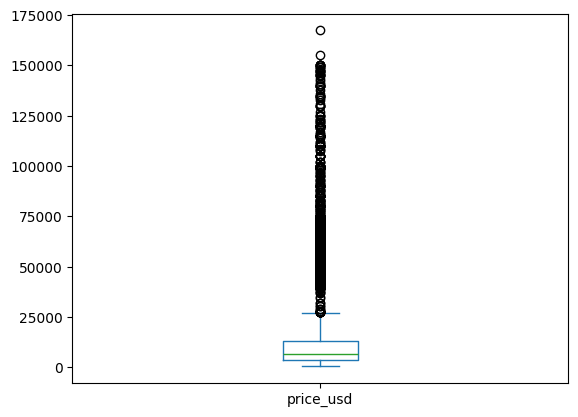

In [556]:
df_clean['price_usd'].plot(kind='box',)

The chart shows bunch of extream values 

In [557]:
# Using statistical measurements
Q1 = df_clean['price_usd'].quantile(0.25)
Q3 = df_clean['price_usd'].quantile(0.75)

IQR = Q3 - Q1
df_clean["is_outlier"] = (df_clean['price_usd'] < Q1 - 1.5*IQR) | (df_clean['price_usd'] > Q3 + 1.5*IQR)

In [558]:
df_clean.head()

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand,price_usd,is_outlier
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,12.0,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada,1250.0,False
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,1.0,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada,1250.0,False
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,2103.0,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada,1250.0,False
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,105.0,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ,1250.0,False
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,16.0,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other,1250.0,False


In [559]:
temp = df_clean[df_clean['is_outlier']== False]

<Axes: >

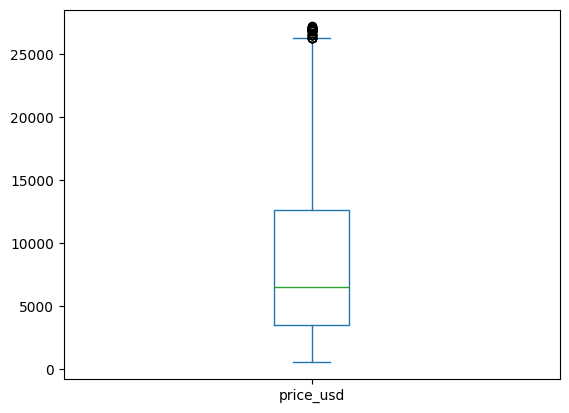

In [560]:
temp["price_usd"].plot(kind='box')

Still after filtering out outliers there are outliers.

---
#### mileage 


In [561]:
df['mileage'].describe()

count    4.549600e+04
mean     2.022740e+05
std      7.109167e+05
min      0.000000e+00
25%      3.887500e+02
50%      7.350000e+04
75%      2.100000e+05
max      1.000000e+07
Name: mileage, dtype: float64

In [562]:
df_clean["mileage"].sort_values(ascending=False)


2420     10000000.0
4891     10000000.0
47640    10000000.0
4359     10000000.0
21583    10000000.0
            ...    
49238           NaN
49247           NaN
49253           NaN
49264           NaN
49266           NaN
Name: mileage, Length: 48273, dtype: float64

That was the wildest part of the cleaning. `mileage` column has serius outliers / dirty values.

In [563]:
df_clean['mileage_raw'] = df_clean['mileage']
df_clean.loc[df_clean['mileage'] > 500000, 'mileage'] = np.nan

In [564]:
df_clean.sample(6)

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand,price_usd,is_outlier,mileage_raw
9725,https://olx.uz/d/obyavlenie/daewoo-lacetti-1-8...,01.04.2025,Bukhara,Buhara,5300.0,USD,Машина холати зур 4 поколения пропан газ кузов...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Lacetti,...,Gasoline/Gas,Excellent,2,"Electrical Mirrors, Electrical Window Lifters,...",Lacetti,Chevrolet Lacetti,Chevrolet,5300.0,False,147398.0
19447,https://olx.uz/d/obyavlenie/mersedes-benz-s200...,24.04.2025,Surkhandarya,Uzun,8000.0,USD,Moshin sotiladi. Malumot uchun +998888088283 r...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 200,...,Gasoline/Gas,Good,1,"Air Conditioner, Electrical Window Lifters, Па...",200,200,Audi,8000.0,False,NaN
33468,https://olx.uz/d/obyavlenie/chevrolet-captiva-...,25.04.2025,Khorezm,Hazarasp,12500.0,USD,Chevrolet Captiva Xolati yahshi muroajat un te...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Captiva,...,Diesel,Good,2,None,Captiva,Chevrolet Captiva,Chevrolet,12500.0,False,100.0
43370,https://olx.uz/d/obyavlenie/captiva-3-yangi-co...,27.04.2025,Bukhara,Gizhduvan,17000.0,USD,Polni shumka bogan yangi yushoq\n balonlar qoy...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Captiva,...,Gasoline,Excellent,2,"Парктроник, Electrical Mirrors, Security Syste...",Captiva,Chevrolet Captiva,Chevrolet,17000.0,False,91000.0
41415,https://olx.uz/d/obyavlenie/gentra-3-pozitsya-...,06.05.2025,Kashkadarya,Kasan,204000000.0,UZS,"Gentra 3 pozitsya rangi oq, avtomat karopka,yi...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Lacetti,...,Gasoline,Good,None,None,Lacetti,Chevrolet Lacetti,Chevrolet,17000.0,False,31000.0
26238,https://olx.uz/d/obyavlenie/spark-sotiladi-201...,14:38-01-Сегодня,Tashkent,TashkentYashnabadskiy rayon,4300.0,USD,Спарк сотилади 2011 2 позиции холати яхши...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Spark,...,Gasoline,Good,2,"Customs Cleared, Electrical Window Lifters, Se...",Spark,Chevrolet Spark,Chevrolet,4300.0,False,330000.0


In [565]:
df_clean['mileage'].isna().sum()

5814

In [566]:
df_clean.loc[
    df_clean["mileage"] == 0,
    ["car_name", "year", "mileage", "price_raw", "description"]
]


,car_name,year,mileage,price_raw,description
2,Lada 2101,1979.0,0.0,15000000.0,Mashin toxlangan metan 100 lik bo 14 diska b...
18,GAZ 2401,1983.0,0.0,15000000.0,Волга газ 2401 сотилади матор килинди \nапкатк...
32,GAZ 69,1982.0,0.0,15000000.0,Мошина ранги яашил матор килинса болди йуради ...
40,Lada 2106,1988.0,0.0,15000000.0,Prapanda moshina elektirkka kursatish kerak k...
65,Lada 2105,1983.0,0.0,15000000.0,Moshinani xarajati yoq mayda chuyda ozmoz ishi...
...,...,...,...,...,...
49205,UAZ 469,1982.0,0.0,30000000.0,"Описание Бистраход каропка, мост, боланлари, а..."
49208,Lada 2106,1989.0,0.0,30000000.0,Описание ЛУАЗ. 1989 йил год выпуска. Двигатель...
49210,Daewoo Nexia,1999.0,0.0,30000000.0,Описание Shumka bugan Hadavoy bugan Mator zver...
49229,UAZ 3303,1982.0,0.0,30000000.0,Описание Уазик сотилади матор 24 акуслятор 4та...


- By looking at the results, a few insights were obtained:
    - Almost all old cars have mileage equal to 0, meaning the owners do not know the mileage count so they didn't specify it.
    - Maybe we will decide the mileage based on price and year.


In [567]:
df_clean.loc[(df_clean['mileage'] < 5000) & (df_clean['price_usd'] < 10000) & (df_clean['year'] < 2023), 'mileage'] = np.nan

This code is based on pure logic. If a car is old and mileage is too low than its not real. If a price also low that it indicates the car is used so those will be marked as missing.

In [568]:
df_clean.loc[(df_clean['mileage'] == 0) &
    (df_clean['year'] < 2024),
    'mileage'
] = np.nan

In [569]:
df_clean['mileage_log'] = np.log1p(df_clean['mileage'])


In [570]:
df_clean['mileage_group'] = pd.cut(
    df_clean['mileage'],
    bins=[-1, 15000, 50000, 100000, 200000, 500000],
    labels=['new_or_very_low', 'low', 'medium', 'high', 'very_high']
)


SO We know 

In [571]:
df_clean['mileage'].describe()

count     36388.000000
mean     129346.030340
std      127112.023135
min           0.000000
25%       12345.000000
50%       96000.000000
75%      210000.000000
max      500000.000000
Name: mileage, dtype: float64

#### engine_volume

In [572]:
df_clean['engine_volume'].value_counts()

engine_volume
1.0       11484
15.0       4813
1500.0     4788
16.0       2492
2.0        2207
          ...  
735.0         1
3578.0        1
935.0         1
734.0         1
788.0         1
Name: count, Length: 795, dtype: int64

In [573]:
df_clean.loc[df_clean['engine_volume'] == 8, ['model_raw', 'year', 'engine_volume']]


,model_raw,year,engine_volume
116,: Tico,1999.0,8.0
197,: 2125 Комби,1988.0,8.0
314,: Tico,1996.0,8.0
552,: Tico,1997.0,8.0
565,: Tico,1998.0,8.0
...,...,...,...
49185,Matiz,2008.0,8.0
49199,Matiz,2012.0,8.0
49212,1119 Kalina хэтчбэк,2008.0,8.0
49218,Matiz,2009.0,8.0


Results suggest values in engine_volume mostly are incorrect. The data still contains noise. Some sellers put model id in engine_volume.


In [574]:
df_clean.loc[df_clean['engine_volume'] == 125]

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,owners_count,additional_options,model_clean,car_name,brand,price_usd,is_outlier,mileage_raw,mileage_log,mileage_group
1245,https://olx.uz/d/obyavlenie/moskvich-21-41-mos...,06.04.2025,Tashkent,Chirchik,1500.0,USD,Москвич 2141 \n1990 г\nКелишамиз. Краска килин...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2141,...,1,Парктроник,2141,Moskvich 2141,Lada,1500.0,False,1000.0,NaN,NaN
1802,https://olx.uz/d/obyavlenie/06-jguli-sotiladi-...,21.04.2025,Navoi,Navoi,18000000.0,UZS,Metan o‘rnatilgan \nXarajati yo‘q\nHolati yaxshi,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2106,...,1,None,2106,Lada 2106,Lada,1500.0,False,333333.0,12.716900,very_high
1891,https://olx.uz/d/obyavlenie/zur-xolat-ala-ID3A...,25.04.2025,Samarkand,Dzhuma,21000000.0,UZS,Xolat. Yaxshi. Rurshi. Idal motor. Moy. Yemad...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2106,...,1,None,2106,Lada 2106,Lada,1750.0,False,NaN,NaN,NaN
2176,https://olx.uz/d/obyavlenie/gaz-3110-soltiladi...,08.04.2025,Bukhara,Buhara,20000000.0,UZS,Metan gaz bor 3 pakaleni. Kuzuvida ishlari bor...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 3110,...,2,"Electrical Mirrors, Electrical Window Lifters,...",3110,GAZ 3110,GAZ,1666.7,False,300000.0,12.611541,very_high
3486,https://olx.uz/d/obyavlenie/moskvich-407-otlic...,28.04.2025,Bukhara,Buhara,25000000.0,UZS,Москвич 407 идеальный состояние 90 413 92 00,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 407,...,1,Customs Cleared,407,Moskvich 407,Other,2083.3,False,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48289,https://olx.uz/d/obyavlenie/nexia-1-oq-sons-ma...,Опубликовано26 апреля 2026,Tashkent,ТашкентУчтепинский район,26000000.0,UZS,Описание 2005 nexia 1 oq sons mator Tramlor ka...,None,None,Nexia,...,2,"Electrical Window Lifters, Security System",Nexia,Daewoo Nexia,Daewoo,2166.7,False,390000.0,12.873905,very_high
48409,https://olx.uz/d/obyavlenie/daewo-damas-1997-I...,Опубликовано30 апреля 2026,Surkhandarya,Бандихон,25000000.0,UZS,Описание Damas sotiladi yili 1997. Metan gazi ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Damas,...,1,Electrical Mirrors,Damas,Daewoo Damas,Daewoo,2083.3,False,200000.0,12.206078,high
48437,https://olx.uz/d/obyavlenie/2004-damas-rusumli...,Опубликовано26 апреля 2026,Tashkent,Паркент,25000000.0,UZS,Описание Eng zoʻri Damas legenda Damas arzon n...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Damas,...,3,Customs Cleared,Damas,Daewoo Damas,Daewoo,2083.3,False,34000.0,10.434145,low
48907,https://olx.uz/d/obyavlenie/matiz-sotiladi-arz...,Опубликовано01 мая 2026,Bukhara,Каган,2200.0,USD,Описание Narmal xolatda matori xadavoy ishi yo...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,Matiz,...,1,Customs Cleared,Matiz,Daewoo Matiz,Daewoo,2200.0,False,250000.0,12.429220,very_high


In [575]:

df_clean['engine_volume_raw'] = df_clean['engine_volume']

def format_engine_value(x):
    if pd.isna(x):
        return np.nan
    if x >= 1000:
        return x / 1000
    if 100 <= x < 1000:
        return x / 100
    if 10 <= x < 100:
        return x / 10
    if 0 < x < 10:
        return x
    return np.nan
df_clean['engine_volume_l'] = df_clean['engine_volume_raw'].apply(format_engine_value)


In [576]:
df_clean["engine_volume_l"].value_counts().sort_index()


engine_volume_l
1.000     12200
1.003         1
1.004         1
1.005         1
1.008         1
          ...  
9.970         2
9.980         1
9.990        33
9.999        19
10.000       39
Name: count, Length: 625, dtype: int64

- Removed incorrect range

In [577]:
df_clean.loc[
    (df_clean['engine_volume_l'] < 0.6) | (df_clean['engine_volume_l'] > 6),
    'engine_volume_l'
] = np.nan

In [578]:
df_clean.sample(5)

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,model_clean,car_name,brand,price_usd,is_outlier,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
48871,https://olx.uz/d/obyavlenie/2001-yil-tiko-xola...,Опубликовано20 апреля 2026,Samarkand,Самарканд,27000000.0,UZS,Описание 2001 yil tiko xolati idial mator karo...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,business,Tico,...,Tico,Daewoo Tico,Daewoo,2250.0,False,234000.0,12.363081,very_high,36.0,3.6
14891,https://olx.uz/d/obyavlenie/hyundai-i20-sotila...,04.05.2025,Tashkent,TashkentShayhantahurskiy rayon,7000.0,USD,Hyundai I20 2013yil sotiladi \nholati zo'r ish...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: i20,...,i20,i20,Other,7000.0,False,169000.0,12.037660,high,12.0,1.2
17086,https://olx.uz/d/obyavlenie/damas2-wan-damas-I...,09.04.2025,Samarkand,Kattakurgan,7500.0,USD,Bir qul minilgan harajati yuq kup yurmagan ish...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Van,...,Van,Van,Other,7500.0,False,48000.0,10.778977,low,65.0,NaN
44304,https://olx.uz/d/obyavlenie/jac-j7-onix-va-mon...,16.04.2025,Andijan,Andizhan,19000.0,USD,JAC J7 motor 1.5 turbina motor 174 ot kuchi\n-...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Другая,...,Другая,Другая,Other,19000.0,False,10.0,2.397895,new_or_very_low,1500.0,1.5
11327,https://olx.uz/d/obyavlenie/neksiya-sons-tramb...,18.04.2025,Tashkent,Ahangaran,5800.0,USD,Балонлари янги межикар 903 пионер мафон Кенвуд...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Nexia,...,Nexia,Daewoo Nexia,Daewoo,5800.0,False,277350.0,12.533039,very_high,1500.0,1.5


In [579]:
df_clean['engine_volume_l'] = df_clean['engine_volume_l'].round(2)

#### Date cleaning


In [580]:
df_clean.sample(5)

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,model_clean,car_name,brand,price_usd,is_outlier,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
39527,https://olx.uz/d/obyavlenie/prodaetsya-gentra-...,04.05.2025,Tashkent,Yangiyul,14500.0,USD,Продается gentra 2023год автомат. бензин и газ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Другая,...,Другая,Другая,Other,14500.0,False,10000.0,9.210440,new_or_very_low,15.0,1.5
40247,https://olx.uz/d/obyavlenie/prodaetsya-mashina...,04.05.2025,Tashkent,Yangiyul,14700.0,USD,Продаётся Машина Chevrolet Captiva 3\n2015 год...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Captiva,...,Captiva,Chevrolet Captiva,Chevrolet,14700.0,False,127.0,4.852030,new_or_very_low,3.0,3.0
9093,https://olx.uz/d/obyavlenie/nexia-1-sotiladi-I...,14.04.2025,Kashkadarya,Shahrisabz,65000000.0,UZS,Nexia 1 sonis alo darajada 4ta eshik pol shumk...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Nexia,...,Nexia,Daewoo Nexia,Daewoo,5416.7,False,279000.0,12.538971,very_high,75.0,NaN
39873,https://olx.uz/d/obyavlenie/gentra-qora-masla-...,06.05.2025,Tashkent,TashkentChilanzarskiy rayon,14300.0,USD,Qora gentra Bez lyuk 2023 24 Qora Yengi moshin...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Lacetti,...,Lacetti,Chevrolet Lacetti,Chevrolet,14300.0,False,20.0,3.044522,new_or_very_low,1.0,1.0
43463,https://olx.uz/d/obyavlenie/monza-turbo-1-3-ID...,12.05.2025,Samarkand,Samarkand,17900.0,USD,Монза 1.3 турбо \nЙили 2023\nПробег 15000\nКра...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Monza,...,Monza,Monza,Other,17900.0,False,15000.0,9.615872,new_or_very_low,1.0,1.0


After inspecting posting_date column, I realized the posting dates in that column is not actually original posting date. Based on my research, Sellers can actually refresh the posting so that their car stays at the top. So this column is not useful for analysis. So i will delete it later on.

In [581]:
df_clean = df_clean.drop(columns=['posting_date'])

#### sale_type cleaning process

In [582]:
df_clean['seller_type'].value_counts()

seller_type
private     39844
business       47
Name: count, dtype: int64

The result shows that seller_type only carries one value that is "private" there? There is no meaning to keep this column so I will drop this column.

In [583]:
df_clean = df_clean.drop(columns=['seller_type'])

In [584]:
df_clean.columns

Index(['url', 'region', 'district', 'price_raw', 'currency', 'description',
       'image_url', 'model_raw', 'body_type', 'sale_type', 'year', 'mileage',
       'transmission', 'color', 'engine_volume', 'fuel_type', 'condition',
       'owners_count', 'additional_options', 'model_clean', 'car_name',
       'brand', 'price_usd', 'is_outlier', 'mileage_raw', 'mileage_log',
       'mileage_group', 'engine_volume_raw', 'engine_volume_l'],
      dtype='object')

#### owners_count cleaning process

In [585]:
df_clean['owners_count'].value_counts()

owners_count
1     29175
2     10750
3      2080
4+     1128
Name: count, dtype: int64

We should change the column type.

In [586]:
def format_owners_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    x = x.strip('+')
    return float(x)

df_clean['owners_count'] = df_clean['owners_count'].apply(format_owners_count)
df_clean['owners_count'] = df_clean['owners_count'].astype('Int64')

In [587]:
df_clean.head()

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,model_clean,car_name,brand,price_usd,is_outlier,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2103,Sedan,None,...,2103,Lada 2103,Lada,1250.0,False,NaN,NaN,NaN,12.0,1.20
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2105,Sedan,Simple Sale,...,2105,Lada 2105,Lada,1250.0,False,72122.0,11.186128,medium,1.0,1.00
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2101,Convertible,None,...,2101,Lada 2101,Lada,1250.0,False,0.0,NaN,NaN,2103.0,2.10
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 31029,Station Wagon,None,...,31029,GAZ 31029,GAZ,1250.0,False,560.0,NaN,NaN,105.0,1.05
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 626,Hatchback,Simple Sale,...,626,626,Other,1250.0,False,NaN,NaN,NaN,16.0,1.60


#### sale_type cleaning process

In [588]:
df_clean['sale_type'].value_counts()

sale_type
Simple Sale                                                   15052
Простая продажа, Рассрочка                                      518
Exchange                                                        392
Простая продажа, Кредит                                         388
Простая продажа, Возможен обмен                                 362
                                                              ...  
Кредит, Простая продажа, Trade-in, Возможен обмен                 1
Рассрочка, Возможен обмен, Кредит, Аренда                         1
Trade-in, Простая продажа, Кредит, Лизинг                         1
Лизинг, Возможен обмен, Простая продажа, Кредит, Рассрочка        1
Аренда, Рассрочка, Возможен обмен, Кредит, Простая продажа        1
Name: count, Length: 354, dtype: int64

In [589]:
Translate_list = {
    "Кредит": "Credit",
    "Рассрочка": "Installment plan",
    "Простая продажа": "Direct sale",
    "Возможен обмен": "Exchange possible",
    "Аренда": "Rent",
    "Лизинг": "Leasing"
}

def translate(text):
    if pd.isna(text):
        return text
    
    items = [item.strip() for item in text.split(",")]
    translated = [Translate_list.get(item, item) for item in items]
    
    return ", ".join(translated)

df_clean["sale_type"] = df_clean["sale_type"].apply(translate)


In [590]:
df_clean.sample(10)

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,model_clean,car_name,brand,price_usd,is_outlier,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
7615,https://olx.uz/d/obyavlenie/prodaetsya-vaz-210...,Tashkent,TashkentSergeliyskiy rayon,2800.0,USD,"Машина на ходу мотор хороший 1,5 продаётся срочно",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 21099,Sedan,Simple Sale,...,21099,Lada Samara 21099,Lada,2800.0,False,NaN,NaN,NaN,1500.0,1.50
9066,https://olx.uz/d/obyavlenie/nexia-1-2006yil-se...,Navoi,Navoi,66000000.0,UZS,Нексия 1 2006-йил серый цвет нормальный состо...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,None,...,Nexia,Daewoo Nexia,Daewoo,5500.0,False,315000.0,12.660331,very_high,1500.0,1.50
28065,https://olx.uz/d/obyavlenie/matin-sotiladi-ezi...,Tashkent,Yangiyul,4800.0,USD,Mowina mator qilingan karopka xadavoy yaxwi fa...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Matiz,Hatchback,None,...,Matiz,Daewoo Matiz,Daewoo,4800.0,False,299000.0,12.608202,very_high,12.0,1.20
9080,https://olx.uz/d/obyavlenie/srochno-sotiladi-s...,Surkhandarya,Angor,65500000.0,UZS,Срочно сотилади SPARK 2012 йил делфин ранг\nПр...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Spark,Hatchback,Simple Sale,...,Spark,Chevrolet Spark,Chevrolet,5458.3,False,398000.0,12.894210,very_high,1000.0,1.00
9550,https://olx.uz/d/obyavlenie/nexia-3-sroshni-so...,Surkhandarya,Angor,70000000.0,UZS,Машина йахши камчилиги бор узига йараша срошни...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,Simple Sale,...,Nexia,Daewoo Nexia,Daewoo,5833.3,False,231.0,NaN,NaN,1.0,1.00
41532,https://olx.uz/d/obyavlenie/honghi-eqm-5-500-k...,Tashkent,TashkentAlmazarskiy rayon,201500000.0,UZS,Bizning Avtosalonimizda Endilikda\n\nBarcha Tu...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Прочее,Sedan,None,...,Прочее,Прочее,Other,16791.7,False,0.0,0.000000,new_or_very_low,1500.0,1.50
13772,https://olx.uz/d/obyavlenie/matiz-best-sotilad...,Tashkent,Eshanguzar,6500.0,USD,Matiz best sotiladi xolati zor qarab xaydalgan...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Matiz,Sedan,None,...,Matiz,Daewoo Matiz,Daewoo,6500.0,False,90000.0,11.407576,medium,1.0,1.00
13803,https://olx.uz/d/obyavlenie/nexia2-qora-2011-I...,Tashkent,Yangibazar,6500.0,USD,Moshina 2011 super kandisaner xolati yaxshi 1q...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,None,...,Nexia,Daewoo Nexia,Daewoo,6500.0,False,350.0,NaN,NaN,108.0,1.08
24305,https://olx.uz/d/obyavlenie/neksiya-2-dons-1-6...,Kashkadarya,Karshi,52000000.0,UZS,Нексия сотилади 2012 йили гидравликали таниров...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Hatchback,Simple Sale,...,Nexia,Daewoo Nexia,Daewoo,4333.3,False,NaN,NaN,NaN,16.0,1.60
25740,https://olx.uz/d/obyavlenie/nexia-2-1-6-dons-2...,Tashkent,TashkentYakkasarayskiy rayon,4200.0,USD,Nexia 2 1.6 2009 holati ortacha prastoy narxi ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,None,...,Nexia,Daewoo Nexia,Daewoo,4200.0,False,225000.0,12.323860,very_high,1600.0,1.60


- `sales_type` column translated
- added back up
- didnt fill `sales_type` column with unknown inorder to avoid extra rows in new table

#### clean year

In [591]:
df_clean.loc[df_clean['year'] <= 1979, ['year','car_name', 'price_usd']]

,year,car_name,price_usd
0,1979.0,Lada 2103,1250.0
2,1979.0,Lada 2101,1250.0
9,1968.0,GAZ 21 Volga,1250.0
15,1974.0,Lada 2106,1250.0
16,1979.0,Lada 2106,1250.0
...,...,...,...
49095,1979.0,Lada Niva,2500.0
49096,1979.0,Другая,2500.0
49099,1977.0,Moskvich 412,2500.0
49100,1978.0,Moskvich 412,2500.0


In [592]:
until_70s = df_clean.loc[df_clean['year'] < 1980]

In [593]:
def devide_eras(x):
    if pd.isna(x):
        return np.nan
    
    if x < 1940:
        return 'pre-1940'
    elif 1940 <= x <= 1949:
        return '1940s'
    elif 1950 <= x <= 1959:
        return '1950s'
    elif 1960 <= x <= 1969:
        return '1960s'
    else:
        return '1970s'
until_70s['era'] = until_70s['year'].apply(devide_eras)


/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_72388/324871218.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  until_70s['era'] = until_70s['year'].apply(devide_eras)


In [594]:
until_70s.groupby('era')['era'].count().sort_values()

era
1940s         8
pre-1940     26
1950s        50
1960s       129
1970s       832
Name: era, dtype: int64


Impossible model-year combos:
---

| Year | Car | Why it's wrong |
|---|---|---|
| 1900 | Moskvich 412, GAZ 2401, Lada 2103, UAZ 469 | These models made 1969–1972 at earliest |
| 1912 | Lada 2107 | Lada 2107 made 1982+ |
| 1918 | Chevrolet Spark | Spark made 2005+ |
| 1919 | Lada Kalina Wagon | Kalina made 2004+ |
| 1920 | Chevrolet Lacetti | Lacetti made 2002+ |
| 1937 | Vivaro | Opel Vivaro made 2001+ |
| 1942 | Moskvich 412 | Moskvich 412 made 1969+ |
| 1947 | UAZ 69 | GAZ-69 production started 1952 |



In [595]:
df_clean["car_name"].value_counts()

car_name
Daewoo Nexia         6669
Chevrolet Lacetti    4982
Daewoo Matiz         4751
Daewoo Damas         4014
Chevrolet Cobalt     3551
                     ... 
B 200                   1
Cami                    1
Skyline                 1
39094                   1
Labo                    1
Name: count, Length: 726, dtype: int64

In [596]:
model_min_year = {

    # LADA (VAZ)
    "Lada 2101": 1970,
    "Lada 2102": 1971,
    "Lada 2103": 1972,
    "Lada 2104": 1984,
    "Lada 2105": 1979,
    "Lada 2106": 1976,
    "Lada 2107": 1982,
    "Lada Samara 2108": 1984,
    "Lada Samara 2109": 1987,
    "Lada Samara 21099": 1990,
    "Lada 21011": 1974,
    "Lada 21013": 1977,
    "Lada 21033": 1972,
    "Lada 21060": 1976,
    "Lada 21061": 1976,
    "Lada 21063": 1976,
    "Lada 21071": 1977,
    "Lada 21073": 1977,
    "Lada Samara 21083": 1987,
    "Lada Samara 21093": 1987,
    "Lada 21102": 1996,
    "Lada 21103": 1996,
    "Lada 21106": 2003,
    "Lada 21111": 1998,
    "Lada 21124": 2004,
    "Lada Niva": 1977,
    "Lada Niva 21214": 1994,
    "Lada Niva 4x4": 1977,
    "Lada Niva Dana": 1998,
    "Lada Kalina": 2004,
    "Lada Kalina Wagon": 2006,
    "Lada Kalina Sedan": 2004,
    "Lada Kalina Hatchback": 2004,
    "Lada 2110": 1996,
    "Lada 2111": 1998,
    "Lada 2112": 1999,
    "Lada 2113": 2004,
    "Lada 2114": 2001,
    "Lada 2115": 1997,

    # GAZ — Volga
    "GAZ 21 Volga": 1956,
    "GAZ 22 Volga": 1962,
    "GAZ 24 Volga": 1970,
    "GAZ 2401": 1970,
    "GAZ 2402": 1972,
    "GAZ 2410 Volga": 1985,
    "GAZ 3102 Volga": 1982,
    "GAZ 31013": 1990,
    "GAZ 31029": 1992,
    "GAZ 3110": 1997,
    "GAZ 3111": 2000,
    "GAZ 3102i": 1982,

    # GAZ — Pobeda
    "GAZ Pobeda M-20": 1946,
    "GAZ Pobeda": 1946,

    # GAZ — Chaika / ZIM / M1
    "GAZ 13 Chaika": 1959,
    "GAZ 12 ZIM": 1950,
    "GAZ M1": 1936,

    # GAZ — off-road / trucks
    "GAZ 69": 1952,
    "GAZ 51": 1946,
    "GAZ 66": 1964,
    "GAZ 67": 1943,

    # MOSKVICH
    "Moskvich 400": 1946,
    "Moskvich 401": 1954,
    "Moskvich 407": 1958,
    "Moskvich 410": 1957,
    "Moskvich 412": 1969,
    "Moskvich 2125 Kombi": 1976,
    "Moskvich 2136 Kombi": 1976,
    "Moskvich 2137": 1978,
    "Moskvich 2137 Kombi": 1978,
    "Moskvich 2140": 1976,
    "Moskvich 2141": 1986,
    "Moskvich 21412": 1986,

    # UAZ
    "UAZ 469": 1972,
    "UAZ 2206": 1985,
    "UAZ 2715": 1965,
    "UAZ 3151": 1985,
    "UAZ 3159": 1998,
    "UAZ 3303": 1985,
    "UAZ 31512": 1985,
    "UAZ 31514": 1993,
    "UAZ 31519": 2000,
    "UAZ Hunter": 2003,

    # ZAZ
    "ZAZ 965": 1960,
    "ZAZ 968": 1971,
    "ZAZ 968M": 1979,
    "ZAZ Tavria": 1988,
    "ZAZ Oka": 1988,
    "ZAZ Sens": 2002,

    # DAEWOO
    "Daewoo Matiz": 1998,
    "Daewoo Nexia": 1995,
    "Daewoo Damas": 1991,
    "Daewoo Tico": 1991,
    "Daewoo Espero": 1990,

    # CHEVROLET (UzAuto)
    "Chevrolet Lacetti": 2002,
    "Chevrolet Gentra": 2013,
    "Chevrolet Cobalt": 2011,
    "Chevrolet Spark": 2005,
    "Chevrolet Malibu": 2011,
    "Chevrolet Tracker": 2013,
    "Chevrolet Onix": 2012,
    "Chevrolet Captiva": 2006,

    # HYUNDAI
    "Hyundai Sonata": 1985,
    "Hyundai Accent": 1994,
    "Hyundai Elantra": 1990,

    # KIA
    "Kia Rio": 2000,
    "Kia Sportage": 1993,

    # VOLKSWAGEN
    "Volkswagen Passat": 1973,
    "Volkswagen Golf": 1974,
    "Volkswagen Golf III": 1991,
    "Volkswagen Golf VI": 2008,
    "Volkswagen Jetta": 1979,
    "Volkswagen Transporter": 1950,
    "Volkswagen Scirocco": 1974,

    # NISSAN
    "Nissan Maxima": 1981,
    "Nissan Skyline GT-R": 1969,
    "Nissan Bluebird": 1957,
    "Nissan R'nessa": 1997,
    "Nissan Pathfinder": 1985,

    # TOYOTA
    "Toyota Corolla": 1966,
    "Toyota Camry": 1982,
    "Toyota Hiace": 1967,
    "Toyota LiteAce": 1970,
    "Toyota Starlet": 1973,

    # FORD
    "Ford Escort": 1968,
    "Ford Fiesta": 1976,
    "Ford Scorpio": 1985,
    "Ford Granada": 1972,
    "Ford Five Hundred": 2004,

    # MERCEDES-BENZ
    "Mercedes-Benz 190": 1982,
    "Mercedes-Benz C250": 1993,
    "Mercedes-Benz E230": 1984,
    "Mercedes-Benz SL320": 1989,
    "Mercedes-Benz S550": 2005,

    # BMW
    "BMW 520": 1972,

    # HONDA
    "Honda Civic": 1972,

    # OPEL
    "Opel Vectra": 1988,
    "Opel Omega": 1986,
    "Opel Ascona": 1970,
    "Opel Rekord": 1953,
    "Opel Admiral": 1964,
    "Opel Vivaro": 2001,

    # FIAT
    "Fiat Uno": 1983,
    "Fiat Croma": 1985,
}

df_clean["year_valid"] = df_clean.apply(
    lambda row: row["year"] >= model_min_year.get(row["car_name"], 0),
    axis=1
)
bad_years = df_clean[~df_clean["year_valid"]][["year", "car_name", "price_usd"]]
print(bad_years)

         year           car_name  price_usd
15     1974.0          Lada 2106     1250.0
17     1988.0          Lada 2111     1250.0
51     1981.0          Lada 2107     1250.0
64     1977.0          Lada 2111     1250.0
74     1973.0          GAZ 31029     1250.0
...       ...                ...        ...
49229  1982.0           UAZ 3303     2500.0
49230  2004.0  Chevrolet Captiva     2500.0
49231  1984.0          Lada 2113     2500.0
49244  1990.0           UAZ 3159     2500.0
49253     NaN               None        NaN

[518 rows x 3 columns]


In [597]:
df_clean[["model_clean","car_name","year_valid"]].sample(6)

,model_clean,car_name,year_valid
16718,Damas,Daewoo Damas,True
22519,Matiz,Daewoo Matiz,True
13083,Damas,Daewoo Damas,True
47959,31029,GAZ 31029,True
42551,Прочее,Прочее,True
13114,Nexia,Daewoo Nexia,True


In [598]:
correction_dict = {
    # TASHKENT CITY - 11 Districts
    "TashkentSergeliyskiy rayon": "Sergeli",
    "Sergeliyskiy rayon": "Sergeli",
    "ТашкентСергелийский район": "Sergeli",
    "Sergeli": "Sergeli",
    
    "TashkentYunusabadskiy rayon": "Yunusabad",
    "Yunusabadskiy rayon": "Yunusabad",
    "ТашкентЮнусабадский район": "Yunusabad",
    "Yunusabad": "Yunusabad",
    
    "TashkentChilanzarskiy rayon": "Chilanzar",
    "Chilanzarskiy rayon": "Chilanzar",
    "ТашкентЧиланзарский район": "Chilanzar",
    "Chilanzar": "Chilanzar",
    
    "TashkentAlmazarskiy rayon": "Almazar",
    "Almazarskiy rayon": "Almazar",
    "ТашкентАлмазарский район": "Almazar",
    "Almazar": "Almazar",
    
    "TashkentMirzo-Ulugbekskiy rayon": "Mirzo-Ulugbek",
    "Mirzo-Ulugbekskiy rayon": "Mirzo-Ulugbek",
    "ТашкентМирзо-Улугбекский район": "Mirzo-Ulugbek",
    "Mirzo-Ulugbek": "Mirzo-Ulugbek",
    
    "TashkentShayhantahurskiy rayon": "Shayhantahur",
    "Shayhantahurskiy rayon": "Shayhantahur",
    "ТашкентШайхантахурский район": "Shayhantahur",
    "Shayhantahur": "Shayhantahur",
    
    "TashkentYashnabadskiy rayon": "Yashnabad",
    "Yashnabadskiy rayon": "Yashnabad",
    "ТашкентЯшнабадский район": "Yashnabad",
    "Yashnabad": "Yashnabad",
    
    "TashkentUchtepinskiy rayon": "Uchtepa",
    "Uchtepinskiy rayon": "Uchtepa",
    "ТашкентУчтепинский район": "Uchtepa",
    "Uchtepa": "Uchtepa",
    
    "TashkentBektemirskiy rayon": "Bektemir",
    "Bektemirskiy rayon": "Bektemir",
    "ТашкентБектемирский район": "Bektemir",
    "Bektemir": "Bektemir",
    
    "TashkentYakkasarayskiy rayon": "Yakkasaray",
    "Yakkasarayskiy rayon": "Yakkasaray",
    "ТашкентЯккасарайский район": "Yakkasaray",
    "Yakkasaray": "Yakkasaray",
    
    "TashkentMirabadskiy rayon": "Mirab",
    "Mirabadskiy rayon": "Mirab",
    "ТашкентМирабадский район": "Mirab",
    "Mirab": "Mirab",
    "Mirabad": "Mirab",
    
    # SAMARKAND REGION
    "Samarkand": "Samarkand",
    "Самарканд": "Samarkand",
    "Urgut": "Urgut",
    "Ургут": "Urgut",
    "Kattakurgan": "Kattakurgan",
    "Каттакурган": "Kattakurgan",
    "Bulungur": "Bulungur",
    "Булунгур": "Bulungur",
    "Panjob": "Panjob",
    "Jomboy": "Jomboy",
    "Джамбай": "Jomboy",
    "Dzhambay": "Jomboy",
    "Narpay": "Narpay",
    "Payariq": "Payariq",
    "Payshanba": "Payshanba",
    "Gazalkent": "Gazalkent",
    "Газалкент": "Gazalkent",
    
    # BUKHARA REGION
    "Buhara": "Bukhara",
    "Bukhara": "Bukhara",
    "Бухара": "Bukhara",
    "Gizhduvan": "Gizhduvan",
    "Гиждуван": "Gizhduvan",
    "Galaasiya": "Galaasiya",
    "Галаасия": "Galaasiya",
    "Karakul": "Karakul",
    "Каракуль": "Karakul",
    "Karmana": "Karmana",
    "Кармана": "Karmana",
    "Kagan": "Kagan",
    "Каган": "Kagan",
    "Romitan": "Romitan",
    "Ромитан": "Romitan",
    "Shafirkan": "Shafirkan",
    "Шафиркан": "Shafirkan",
    "Vabkent": "Vabkent",
    "Вабкент": "Vabkent",
    "Eshanguzar": "Eshanguzar",
    "Эшангузар": "Eshanguzar",
    "Koshkupyr": "Koshkupyr",
    "Nurafshan (Toytepa)": "Nurafshan",
    "Нурафшан (Тойтепа)": "Nurafshan",
    "Nurata": "Nurata",
    "Нурата": "Nurata",
    
    # FERGANA REGION
    "Fergana": "Fergana",
    "Фергана": "Fergana",
    "Kokand": "Kokand",
    "Коканд": "Kokand",
    "Margilan": "Margilan",
    "Маргилан": "Margilan",
    "Yangi Margilan": "Margilan",
    "Янги Маргилан": "Margilan",
    "Rishtan": "Rishtan",
    "Риштан": "Rishtan",
    "Bustan": "Bustan",
    "Бустан": "Bustan",
    "Kuva": "Quva",
    "Кува": "Quva",
    "Quva": "Quva",
    "Kuvasay": "Quvasoy",
    "Кувасай": "Quvasoy",
    "Quvasoy": "Quvasoy",
    "Andizhan": "Andijan",
    "Андижан": "Andijan",
    "Asaka": "Asaka",
    "Асака": "Asaka",
    "Balykchi": "Baliqchi",
    "Балыкчи": "Baliqchi",
    "Yangiabad": "Yangiabad",
    "Chust": "Chust",
    "Чуст": "Chust",
    "Yoqoq": "Yoqoq",
    "Ozbekiston": "Ozbekiston",
    "Uychi": "Uychi",
    "Yo'qoq": "Yoqoq",
    "Keles": "Keles",
    "Келес": "Keles",
    "Iskandar": "Iskandar",
    "Iskandarkul": "Iskandarkul",
    
    # ANDIJAN REGION
    "Aldiariq": "Aldiariq",
    "Altiariq": "Altiariq",
    "Altiariq": "Altiariq",
    "Altyaryk": "Altiariq",
    "Алтыарык": "Altiariq",
    "Marhamat": "Marhamat",
    "Мархамат": "Marhamat",
    "Pahtaabad": "Pahtaabad",
    "Paxta-abad": "Pahtaabad",
    "Paxta-abad": "Pahtaabad",
    "Qorasuv": "Qorasuv",
    "Khonaabad": "Khonaabad",
    
    # NAMANGAN REGION
    "Namangan": "Namangan",
    "Наманган": "Namangan",
    "Chust": "Chust",
    "Чуст": "Chust",
    "Kosonsoy": "Kosonsoy",
    "Mingbul": "Mingbul",
    "Norin": "Norin",
    "Pop": "Pop",
    "Uchqorghon": "Uchqorghon",
    "Yangikurgan": "Yangikurgan",
    "Янгикурган": "Yangikurgan",
    "Navbahor": "Navbahor",
    "Turk'estan": "Turkestan",
    "Turkestan": "Turkestan",
    
    # KASHKADARYA REGION
    "Karshi": "Karshi",
    "Карши": "Karshi",
    "Carshi": "Karshi",
    "Ambul": "Ambul",
    "Chiroqchi": "Chiroqchi",
    "Chirakchi": "Chiroqchi",
    "Чиракчи": "Chiroqchi",
    "Dehkanabad": "Dehkanabad",
    "Дехканабад": "Dehkanabad",
    "Guzar": "Guzar",
    "Гузар": "Guzar",
    "Kasbi": "Kasbi",
    "Касби": "Kasbi",
    "Kitab": "Kitob",
    "Китаб": "Kitob",
    "Koson": "Koson",
    "Mubarek": "Mubarek",
    "Мубарек": "Mubarek",
    "Nishon": "Nishon",
    "Qamashi": "Qamashi",
    "Камаши": "Qamashi",
    "Shahrisabz": "Shahrisabz",
    "Шахрисабз": "Shahrisabz",
    "Shurchi": "Shurchi",
    "Шурчи": "Shurchi",
    "Yakkabag": "Yakkabag",
    "Яккабаг": "Yakkabag",
    "Yoshli": "Yoshli",
    "Zamin": "Zamin",
    "Zaamin": "Zamin",
    "Shargun": "Shargun",
    "Шаргунь": "Shargun",
    "Pitnak": "Pitnak",
    
    # SURKHANDARYA REGION
    "Termez": "Termiz",
    "Термез": "Termiz",
    "Angor": "Angor",
    "Ангор": "Angor",
    "Bandihon": "Bandihon",
    "Бандихон": "Bandihon",
    "Baysun": "Baysun",
    "Байсун": "Baysun",
    "Denau": "Denau",
    "Денау": "Denau",
    "Jarqorghon": "Jarqorghon",
    "Qiziriq": "Qiziriq",
    "Кизирик": "Qiziriq",
    "Kizirik": "Qiziriq",
    "Qumqorghon": "Qumqorghon",
    "Sariasiya": "Sariasoya",
    "Сариасия": "Sariasoya",
    "Sherabad": "Sherabad",
    "Шерабад": "Sherabad",
    "Shorchi": "Shorchi",
    "Шурчи": "Shorchi",
    "Shurchi": "Shorchi",
    "Surkhan": "Surkhan",
    "Uzun": "Uzun",
    "Узун": "Uzun",
    "Hodzheyli": "Hodzheyli",
    "Ходжейли": "Hodzheyli",
    "Sayhun": "Sayhun",
    "Сайхун": "Sayhun",
    "Payshanba": "Payshanba",
    "Пайшанба": "Payshanba",
    "Hankabad": "Hankabad",
    "Dangarah": "Dangara",
    "Dangara": "Dangara",
    "Дангара": "Dangara",
    "Ziadin": "Ziadin",
    "Зиадин": "Ziadin",
    "Dustlik": "Dustlik",
    "Дустлик": "Dustlik",
    
    # NAVOI REGION
    "Navoi": "Navoi",
    "Навои": "Navoi",
    "Qaragum": "Qaragum",
    "Konimex": "Konimex",
    "Nurata": "Nurata",
    "Нурата": "Nurata",
    "Tomdi": "Tomdi",
    "Uchkuduk": "Uchkuduk",
    "Учкудук": "Uchkuduk",
    "Zafarimni": "Zafarimni",
    "Akaltyn": "Akaltyn",
    "Aydarkul": "Aydarkul",
    
    # JIZZAKH REGION
    "Dzhizak": "Jizzakh",
    "Джизак": "Jizzakh",
    "Jizzakh": "Jizzakh",
    "Arnasoy": "Arnasoy",
    "Dostlik": "Dostlik",
    "Дустлик": "Dostlik",
    "Do'stlik": "Dostlik",
    "Forish": "Forish",
    "Galaba": "Galaba",
    "G'alaba": "Galaba",
    "Mirzachol": "Mirzachol",
    "Mirzacho'l": "Mirzachol",
    "Paxtakor": "Paxtakor",
    "Пахтакор": "Paxtakor",
    "Pahtakor": "Paxtakor",
    "Yangiobod": "Yangiobod",
    "Zafarabad": "Zafarabad",
    "Зафарабад": "Zafarabad",
    "Zarbdor": "Zarbdor",
    "Зарбдар": "Zarbdor",
    "Zarbdar": "Zarbdor",
    "Sardoba": "Sardoba",
    "Сардоба": "Sardoba",
    "Tamdybulak": "Tamdybulak",
    "Tамдыбулак": "Tamdybulak",
    "Yangiyor": "Yangiyor",
    "Syrdarya": "Syrdarya",
    "Сырдарья": "Syrdarya",
    "Cyrdarya": "Syrdarya",
    "Cырдарья": "Syrdarya",
    "Dzhuma": "Dzhuma",
    "Джума": "Dzhuma",
    "Dustabad": "Dustabad",
    "Zarafshan": "Zarafshan",
    "Зарафшан": "Zarafshan",
    "Gulistan": "Gulistan",
    "Гулистан": "Gulistan",
    "Karakul": "Karakul",
    "Karakul": "Karakul",
    "Kanylikul": "Kanylikul",
    "Kanlykul": "Kanylikul",
    
    # TASHKENT REGION
    "Chirchik": "Chirchik",
    "Чирчик": "Chirchik",
    "Yangiyul": "Yangiyul",
    "Янгиюль": "Yangiyul",
    "Angren": "Angren",
    "Ангрен": "Angren",
    "Ahangaran": "Ahangaran",
    "Ахангаран": "Ahangaran",
    "Bekabad": "Bekabad",
    "Бекабад": "Bekabad",
    "Gazalkent": "Gazalkent",
    "Газалкент": "Gazalkent",
    "Kibray": "Kibray",
    "Кибрай": "Kibray",
    "Pskent": "Pskent",
    "Пскент": "Pskent",
    "Tashkent": "Tashkent",
    "Ozarbayev": "Ozarbayev",
    
    # KARAKALPAKSTAN
    "Nukus": "Nukus",
    "Нукус": "Nukus",
    "Urgench": "Urgench",
    "Ургенч": "Urgench",
    "Amudarya": "Amudarya",
    "Beruniy": "Beruniy",
    "Берни": "Beruniy",
    "Beruni": "Beruniy",
    "Chimboy": "Chimboy",
    "Чимбай": "Chimboy",
    "Chimbay": "Chimboy",
    "Qanlikul": "Qanlikul",
    "Qorauzak": "Qorauzak",
    "Qongirot": "Qongirot",
    "Takhtakopir": "Takhtakopir",
    "Turtkul": "Turtkul",
    "Турткуль": "Turtkul",
    "Xojayli": "Xojayli",
    "Khojayli": "Xojayli",
    "Hiva": "Hiva",
    "Хива": "Hiva",
    "Khiva": "Hiva",
    "Hazarasp": "Hazarasp",
    "Хазарасп": "Hazarasp",
    "Muynak": "Muynak",
    "Gazli": "Gazli",
    "Kungrad": "Kungrad",
    "Kegeyli": "Kegeyli",
    "Jumbay": "Jumbay",
    "Zhondor": "Zhondor",
    "Жондор": "Zhondor",
    "Zangiata": "Zangiata",
    "Зангиата": "Zangiata",
    
    # SMALLER CITIES & DISTRICTS
    "Nazarbek": "Nazarbek",
    "Назарбек": "Nazarbek",
    "Almalyk": "Almalyk",
    "Алмалык": "Almalyk",
    "Parkent": "Parkent",
    "Паркент": "Parkent",
    "Karaul": "Karaul",
    "Караул": "Karaul",
    "Gyulabad": "Gyulabad",
    "Гюлабад": "Gyulabad",
    "Kyzyltepa": "Kyzyltepa",
    "Кызылтепа": "Kyzyltepa",
    "Yangibazar": "Yangibazar",
    "Янгибазар": "Yangibazar",
    "Koksaray": "Koksaray",
    "Коксарай": "Koksaray",
    "Guzalkent": "Guzalkent",
    "Гузалкент": "Guzalkent",
    "Tashmore": "Tashmore",
    "Ташморе": "Tashmore",
    "Karakul": "Karakul",
    "Hanka": "Hanka",
    "Ханка": "Hanka",
    "Darband": "Darband",
    "Dzharkurgan": "Dzharkurgan",
    "Tahiatash": "Tahiatash",
    "Тахиаташ": "Tahiatash",
    "Laish": "Laish",
    "Лаиш": "Laish",
    "Usmat": "Usmat",
    "Усмат": "Usmat",
    "Chartak": "Chartak",
    "Bagdad": "Bagdad",
    "Багдад": "Bagdad",
    "Yangier": "Yangier",
    "Янгиер": "Yangier",
    "Payaryk": "Payaryk",
    "Пайарык": "Payaryk",
    "Gurlen": "Gurlen",
    "Гурлен": "Gurlen",
    "Altyaryk": "Altyaryk",
    "Алтыарык": "Altyaryk",
    "Uchkyzyl": "Uchkyzyl",
    "Учкызыл": "Uchkyzyl",
    "Uchkuduk": "Uchkuduk",
    "Учкудук": "Uchkuduk",
    "Uchkuprik": "Uchkuprik",
    "Учкуприк": "Uchkuprik",
    "Uchkurgan": "Uchkurgan",
    "Dzhuma": "Dzhuma",
    "Джума": "Dzhuma",
    "Hodzhikent": "Hodzhikent",
    "Hodzhaabad": "Hodzhaabad",
    "Ходжаабад": "Hodzhaabad",
    "Kasansay": "Kasansay",
    "Касансай": "Kasansay",
    "Kasbi": "Kasbi",
    "Касби": "Kasbi",
    "Kasan": "Kasan",
    "Касан": "Kasan",
    "Chilek": "Chilek",
    "Чилек": "Chilek",
    "Chiliz": "Chilek",
    "Chinaz": "Chinaz",
    "Чиназ": "Chinaz",
    "Akkurgan": "Akkurgan",
    "Аккурган": "Akkurgan",
    "Aktash": "Aktash",
    "Акташ": "Aktash",
    "Alat": "Alat",
    "Алат": "Alat",
    "Beshkent": "Beshkent",
    "Бешкент": "Beshkent",
    "Besharyk": "Besharyk",
    "Beshrabat": "Beshrabat",
    "Бешрабат": "Beshrabat",
    "Buka": "Buka",
    "Бука": "Buka",
    "Bulakbashi": "Bulakbashi",
    "Булакбаши": "Bulakbashi",
    "Charvak": "Charvak",
    "Чарвак": "Charvak",
    "Dasht": "Dasht",
    "Dashtobod": "Dashtobod",
    "Даштобод": "Dashtobod",
    "Durmen": "Durmen",
    "Dzhigora": "Dzhigora",
    "Eshankol": "Eshankol",
    "Gagarin": "Gagarin",
    "Гагарин": "Gagarin",
    "Goliblar": "Goliblar",
    "Голиблар": "Goliblar",
    "Gulbahor": "Gulbahor",
    "Гульбахор": "Gulbahor",
    "Hamza": "Hamza",
    "Хамза": "Hamza",
    "Halkabad": "Halkabad",
    "Халкабад": "Halkabad",
    "Hakkulabad": "Hakkulabad",
    "Havast": "Havast",
    "Хаваст": "Havast",
    "Ishtyhan": "Ishtyhan",
    "Иштыхан": "Ishtyhan",
    "Kamanshi": "Kamanshi",
    "Kamashi": "Kamashi",
    "Кармана": "Kamashi",
    "Kanimeh": "Kanimeh",
    "Канимех": "Kanimeh",
    "Karashina": "Karashina",
    "Karasu": "Karasu",
    "Karaulbazar": "Karaulbazar",
    "Караулбазар": "Karaulbazar",
    "Karauzyak": "Karauzyak",
    "Caracol": "Caracol",
    "Carluk": "Carluk",
    "Karluk": "Carluk",
    "Карлук": "Carluk",
    "Chalysh": "Chalysh",
    "Чалыш": "Chalysh",
    "Chirakchi": "Chirakchi",
    "Чиракчи": "Chirakchi",
    "Cukok": "Cukok",
    "Cукок": "Cukok",
    "Chusti": "Chust",
    "Denau": "Denau",
    "Dhigora": "Dhigora",
    "Uchkurgan": "Uchkurgan",
    "Kumkurgan": "Kumkurgan",
    "Кумкурган": "Kumkurgan",
    "Kurgantepa": "Kurgantepa",
    "Кургантепа": "Kurgantepa",
    "Kuyganyar": "Kuyganyar",
    "Куйганъяр": "Kuyganyar",
    "Koshkupyr": "Koshkupyr",
    "Kosonsoy": "Kosonsoy",
    "Kushrabad": "Kushrabad",
    "Кушрабад": "Kushrabad",
    "Langar": "Langar",
    "Лангар": "Langar",
    "Mangit": "Mangit",
    "Мангит": "Mangit",
    "Mardzhanbulak": "Mardzhanbulak",
    "Марджанбулак": "Mardzhanbulak",
    "Mirishkor": "Mirishkor",
    "Yangi Mirishkor": "Mirishkor",
    "Muglan": "Muglan",
    "Муглан": "Muglan",
    "Muzrabad": "Muzrabad",
    "Navruz": "Navruz",
    "Навруз": "Navruz",
    "Nurabad": "Nurabad",
    "Нурабад": "Nurabad",
    "Pap": "Pap",
    "Пап": "Pap",
    "Pahtaabad": "Pahtaabad",
    "Paytug": "Paytug",
    "Пайтуг": "Paytug",
    "Ravan": "Ravan",
    "Salar": "Salar",
    "Салар": "Salar",
    "Saryk": "Saryk",
    "Сарык": "Saryk",
    "Shafirkan": "Shafirkan",
    "Shahrihan": "Shahrihan",
    "Шахрихан": "Shahrihan",
    "Shavat": "Shavat",
    "Шават": "Shavat",
    "Sheron": "Sheron",
    "Shahimardan": "Shahimardan",
    "Shumanay": "Shumanay",
    "Shurkhan": "Shurkhan",
    "Shirin": "Shirin",
    "Ширин": "Shirin",
    "Tashlak": "Tashlak",
    "Ташлак": "Tashlak",
    "Tashbulak": "Tashbulak",
    "Ташбулак": "Tashbulak",
    "Taylak": "Taylak",
    "Тайлак": "Taylak",
    "Terenozek": "Terenozek",
    "Talimardzhan": "Talimardzhan",
    "Turakurgan": "Turakurgan",
    "Туракурган": "Turakurgan",
    "Urtaaul": "Urtaaul",
    "Уртааул": "Urtaaul",
    "Yangi-Nishan": "Yangi-Nishan",
    "Янги-Нишан": "Yangi-Nishan",
    "Yangiabod": "Yangiabod",
    "Yangikishlak": "Yangikishlak",
    "Янгикишлак": "Yangikishlak",
    "Yangirabat": "Yangirabat",
    "Янгирабат": "Yangirabat",
    "Yaypan": "Yaypan",
    "Яйпан": "Yaypan",
    "Yazyavan": "Yazyavan",
    "Язъяван": "Yazyavan",
    "Zafar": "Zafar",
    "Zarbdar": "Zarbdar",
    "Zarbdar": "Zarbdar",
    "Baht": "Baht",
    "Бахт": "Baht",
    "Bayaut": "Bayaut",
    "Баяут": "Bayaut",
    "Bolshoy Chimgan": "Bolshoy Chimgan",
    "Bulungur": "Bulungur",
    "Булунгур": "Bulungur",
    "Cyllak": "Chilek",
    "Ahunbabaev": "Ahunbabaev",
    "Akmangit": "Akmangit",
    "Altynkul": "Altynkul",
    "Алтынкуль": "Altynkul",
    "Balandchakir": "Balandchakir",
    "Bagat": "Bagat",
    "Бандихон": "Bagat",
    "Boz": "Boz",
    "Боз": "Boz",
    "Krasnogorsk": "Krasnogorsk",
    "Красногорск": "Krasnogorsk",
    "Kumkurgan": "Kumkurgan",
    "Kymurgon": "Kumkurgan",
    "Dzhigora": "Dzhigora",
    "Djigora": "Dzhigora",
    "Eshankul": "Eshankul",
    "Gallaaral": "Gallaaral",
    "Gallaaral": "Gallaaral",
    "Qomur-Soy": "Qomur-Soy",
    "Sherabad": "Sherabad",
    "Tahtakupyr": "Tahtakupyr",
    "Talimardzhan": "Talimardzhan",
    "Terenozek": "Terenozek",
    "Vuadil": "Vuadil",
}

In [599]:
import re

df_clean['district_clean'] = df_clean['district'].replace(correction_dict)

def normalize_district(x):
    x = str(x).strip()
    x = re.sub(r'район|rayon', '', x, flags=re.IGNORECASE)
    x = x.replace('Tashkent', '')
    return x.strip()


df_clean['district'] = df_clean['district_clean'].apply(normalize_district)

In [600]:
df_clean.head()

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,brand,price_usd,is_outlier,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l,year_valid,district_clean
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2103,Sedan,None,...,Lada,1250.0,False,NaN,NaN,NaN,12.0,1.20,True,Gallaaral
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2105,Sedan,Simple Sale,...,Lada,1250.0,False,72122.0,11.186128,medium,1.0,1.00,True,Namangan
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2101,Convertible,None,...,Lada,1250.0,False,0.0,NaN,NaN,2103.0,2.10,True,Karaul
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 31029,Station Wagon,None,...,GAZ,1250.0,False,560.0,NaN,NaN,105.0,1.05,True,Mardzhanbulak
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 626,Hatchback,Simple Sale,...,Other,1250.0,False,NaN,NaN,NaN,16.0,1.60,True,Kungrad


## Missing values
### Choose between drop vs impute
Rures:  
>Rows will be dropped when following happens
- success is missing
- missingness is tiny AND dropping won’t distort groups
- row is corrupted in many columns
  
>Impute when:
- dropping would remove too many rows
- missingness is moderate and you need those records
- you can impute in a way that keeps values realistic

In [601]:
df_clean['car_age'] = 2026 - df_clean['year']

In [602]:
df_clean.head()

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,price_usd,is_outlier,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l,year_valid,district_clean,car_age
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2103,Sedan,None,...,1250.0,False,NaN,NaN,NaN,12.0,1.20,True,Gallaaral,47.0
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2105,Sedan,Simple Sale,...,1250.0,False,72122.0,11.186128,medium,1.0,1.00,True,Namangan,44.0
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2101,Convertible,None,...,1250.0,False,0.0,NaN,NaN,2103.0,2.10,True,Karaul,47.0
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 31029,Station Wagon,None,...,1250.0,False,560.0,NaN,NaN,105.0,1.05,True,Mardzhanbulak,30.0
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 626,Hatchback,Simple Sale,...,1250.0,False,NaN,NaN,NaN,16.0,1.60,True,Kungrad,40.0


In [631]:
model_prep = df_clean[['brand', 'year', 'mileage', 'engine_volume_l', 'fuel_type', 'transmission', 
   'body_type', 'condition', 'owners_count', 'region', 'color','price_usd']]

In [632]:
model_prep.columns

Index(['brand', 'year', 'mileage', 'engine_volume_l', 'fuel_type',
       'transmission', 'body_type', 'condition', 'owners_count', 'region',
       'color', 'price_usd'],
      dtype='object')

In [633]:
missing = model_prep.isnull().sum()
missing_pct = (missing/len(model_prep)) * 100
missing_df = pd.DataFrame({'count':missing, 'percentage': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False)
print(missing_df)

                 count  percentage
mileage          11885   24.620388
engine_volume_l   5633   11.669049
owners_count      5140   10.647774
price_usd          156    0.323162
region             152    0.314876
year               151    0.312804
fuel_type          151    0.312804
transmission       151    0.312804
body_type          151    0.312804
condition          151    0.312804
color              151    0.312804


In [634]:
print(len(model_prep))

48273


In [643]:
model_prep = model_prep.dropna(subset=['color', 'region', 'price_usd'])

In [636]:
missing = model_prep.isnull().sum()
missing_pct = (missing/len(model_prep)) * 100
missing_df = pd.DataFrame({'count':missing, 'percentage': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False)
print(missing_df)

                 count  percentage
mileage          11734   24.384364
engine_volume_l   5482   11.392116
owners_count      4989   10.367615
price_usd            5    0.010390


In [637]:
model_prep['mileage'] = model_prep.groupby('brand')['mileage'].transform(
    lambda x: x.fillna(x.median())
).fillna(model_prep['mileage'].median())

In [638]:
model_prep['engine_volume_l'] = model_prep.groupby(['brand', 'fuel_type'])['engine_volume_l'].transform(
    lambda x: x.fillna(x.median())
).fillna(model_prep['engine_volume_l'].median())

In [641]:
def format_owners_count(x):
    if pd.isna(x):
        return np.nan
    else:
        return int(x)

model_prep['owners_count'] = model_prep['owners_count'].apply(format_owners_count)
model_prep['owners_count'] = model_prep['owners_count'].fillna(model_prep['owners_count'].median())


In [647]:
model_prep['age'] = 2026 - model_prep['year']

In [649]:
model_prep=model_prep.drop(columns=['year'])

In [644]:
missing = model_prep.isnull().sum()
missing_pct = (missing/len(model_prep)) * 100
missing_df = pd.DataFrame({'count':missing, 'percentage': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False)
print(missing_df)

Empty DataFrame
Columns: [count, percentage]
Index: []


In [645]:
model_prep.head()

,brand,year,mileage,engine_volume_l,fuel_type,transmission,body_type,condition,owners_count,region,color,price_usd
0,Lada,1979.0,98432.5,1.20,Gasoline/Gas,Manual,Sedan,Good,2.0,Jizzakh,Red,1250.0
1,Lada,1982.0,72122.0,1.00,Gasoline/Gas,Manual,Sedan,Average,1.0,Namangan,Green,1250.0
2,Lada,1979.0,98432.5,2.10,Gasoline/Gas,Manual,Convertible,Good,4.0,Khorezm,White,1250.0
3,GAZ,1996.0,147000.0,1.05,Gasoline/Gas,Manual,Station Wagon,Good,2.0,Jizzakh,White,1250.0
4,Other,1986.0,23500.0,1.60,Gasoline/Gas,Manual,Hatchback,Needs Repair,1.0,Karakalpakstan,White,1250.0


In [650]:
model_prep.to_csv('/Users/javohireshonov/Desktop/Study/Projects/Uzbekistan car postings /data/Prepared/prep_model.csv', index=False)